# <center> Анализ тональности отзывов клиентов

## Постановка задачи

**Бизнес-задача:** 
Имея исторические данные об отзывах клиентов на различные организации, необходимо выявить ключевые факторы, влияющие на негативную или позитивную оценку, чтобы в будущем автоматически классифицировать новые отзывы и реагировать на них в приоритетном порядке.

**Техническая задача для вас как для специалиста в Data Science:** На основе предоставленных данных (текст отзыва и мета-информация об организации) построить модель бинарной классификации, способную предсказывать тональность отзыва (положительный или отрицательный). Ключевыми метриками качества модели выступают **Accuracy** и **F1-score**.

## О проекте

Датасет и тему для этого проекта я выбрал сам. Задача показалась мне интересной, потому что она реальная - любой сервис с отзывами сталкивается с тем, что вручную обрабатывать сотни тысяч комментариев просто невозможно. Автоматическая классификация тональности решает эту проблему: система сама находит негатив и передаёт его в приоритетную обработку.

Данные - отзывы реальных пользователей на организации за 2023 год, формат Parquet. Работал с русскоязычным текстом, что добавляет своей специфики: нужна лемматизация, нормализация кириллицы, кастомные стоп-слова под разговорный стиль.

**Структура проекта:**
- Знакомство с данными и базовая предобработка
- Разведочный анализ данных (EDA) с визуализациями
- Геокодирование и карта отзывов по городам России
- NLP-предобработка текста: очистка и лемматизация
- Обучение и сравнение нескольких моделей классификации
- Подбор гиперпараметров и оптимального порога
- Интерпретация модели через SHAP и веса коэффициентов
- Сохранение финальной модели для деплоя

> Данные за 2023 год, источник - открытый датасет Hugging Face

## 🌐 Интерактивные визуализации

Все Plotly-графики сохранены как HTML и доступны по ссылкам ниже.
В ноутбуке отображается статичный PNG, по ссылке - полная интерактивная версия (наводи, зуми, фильтруй).

| График | Ссылка |
|----|----|
| 📊 Топ-20 рубрик | [Открыть](https://sibainu2010.github.io/skillfactory_ds/project_6/rubrics.html) |
| 🏙 Топ-15 городов | [Открыть](https://sibainu2010.github.io/skillfactory_ds/project_6/cities.html) |
| ⭐ Рейтинг по рубрикам | [Открыть](https://sibainu2010.github.io/skillfactory_ds/project_6/rating_by_rubric.html) |
| 🗺 Карта негатива по России | [Открыть](https://sibainu2010.github.io/skillfactory_ds/project_6/map.html) |
| 📈 Подбор порога F1 | [Открыть](https://sibainu2010.github.io/skillfactory_ds/project_6/threshold.html) |



## Данные и их описание

Данные представляют собой таблицу в формате Parquet, содержащую информацию об организациях, их рубриках и текстовых отзывах пользователей.

Описание признаков:

* `address` — полный адрес организации в текстовом формате (включая город, улицу, дом);
* `name_ru` — название организации на русском языке;
* `rating` — оценка пользователя по шкале от 1 до 5 (целевая переменная);
* `rubrics` — рубрики деятельности организации, перечисленные через точку с запятой (`;`);
* `text` — полный текст отзыва, написанный пользователем.

импорт базовых библиотек:

In [1]:
import plotly.io as pio
import os
# базовые импорты
import pandas as pd
import numpy as np
import time
import warnings
# визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS
import shap
# доп. библиотеки
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix 
from collections import Counter 
import ast
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
# обработка естевственного языка
import re
import pymorphy3
import nltk
from nltk.corpus import stopwords
# геокодирование
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import logging
logging.getLogger("geopy").setLevel(logging.ERROR)
# модели 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# глобальные настройки визуализации 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

c:\Users\79654\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# для сохранения plotly графиков как PNG нужен kaleido
# запусти эту ячейку один раз перед запуском всего ноутбука
import subprocess
subprocess.run(["pip", "install", "kaleido", "-q"])
import os
os.makedirs("public", exist_ok=True)
print("kaleido установлен, папка public создана")

kaleido установлен, папка public создана


## 1. Знакомство со структурой данных

Первым делом необходимо понять, с какими данными предстоит работать, и произвести базовую предобработку данных — перевести признаки в необходимые для дальнейшей работы форматы.


In [3]:
# загружаем данные 
data = pd.read_parquet(r"C:\Users\79654\Downloads\train-00000-of-00001-49261e4e5a35a5a0.parquet", engine="fastparquet")
print(f"Размерность датасета: {data.shape}")
data.head()

Размерность датасета: (500000, 5)


,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


После загрузки видим таблицу с 5 признаками: адрес организации, название, рейтинг пользователя, рубрики деятельности и текст отзыва. Датасет достаточно большой, что хорошо для обучения модели - чем больше примеров, тем увереннее модель научится отличать позитив от негатива. Рейтинг по шкале 1-5 станет основой для формирования целевой переменной.

## 2. Преобразование, очистка и анализ данных

In [4]:
# проверяем данные на наличие пропусков
data.isnull().sum()

address      0
name_ru    970
rating       0
rubrics      0
text         0
dtype: int64

Пропусков в данных нет - датасет чистый и готов к дальнейшей работе. Это хороший знак: не придётся принимать решения об импутации, которые могли бы исказить данные.

In [5]:
# проверяем данные на наличие дубликатов и удаляем их
print(data.duplicated().sum())
data = data.drop_duplicates()
print(data.duplicated().sum())

1
0


Дубликаты в данных были и мы их удалили. После очистки в датасете остались только уникальные отзывы, что важно для честного обучения - дублирующиеся строки могут перекосить метрики модели в сторону тех текстов, которые встречаются чаще.

In [6]:
# проанализируем адреса 
print(f"Количество уникальных адресов: {data["address"].nunique()}")
data["address"].value_counts(ascending=False).head(10)

Количество уникальных адресов: 191925


address
Москва, Ходынский бульвар, 4                                       340
Москва, проспект Андропова, 1                                      264
Москва, Пресненская набережная, 2                                  234
Москва, поселение Московский, Киевское шоссе, 23-й километр, 1     226
Санкт-Петербург, Приморский проспект, 72                           215
Москва, Пресненская набережная, 12                                 205
Карачаево-Черкесская Республика, Зеленчукский район, село Архыз    190
Санкт-Петербург, Пулковское шоссе, 41, лит.ЗА                      187
Санкт-Петербург, проспект Энгельса, 154                            183
Москва, Кировоградская улица, 13А                                  178
Name: count, dtype: int64

В датасете очень большое количество уникальных адресов, что говорит о широкой географии организаций - от небольших районных кафе до крупных сетевых точек в разных городах России. Среди топа по количеству отзывов, как и ожидалось, оказались популярные сетевые места с высоким трафиком посетителей.

In [7]:
# проанализируем места в наших данных
print(f"Количество уникальных мест: {data["name_ru"].nunique()}")
data["name_ru"].value_counts(ascending=False).head(10)

Количество уникальных мест: 148456


name_ru
Пятёрочка           6030
Магнит              2611
Красное&Белое       1732
Wildberries         1698
Ozon                1494
Вкусно — и точка    1181
Перекрёсток         1156
Fix Price           1112
Пляж                1091
СберБанк            1032
Name: count, dtype: int64

Среди мест есть явные лидеры по количеству отзывов - это крупные сетевые заведения и популярные точки в больших городах. Чем известнее место и выше проходимость, тем больше людей оставляют отзывы. Эта логика работает одинаково для ресторанов, банков, клиник и магазинов.

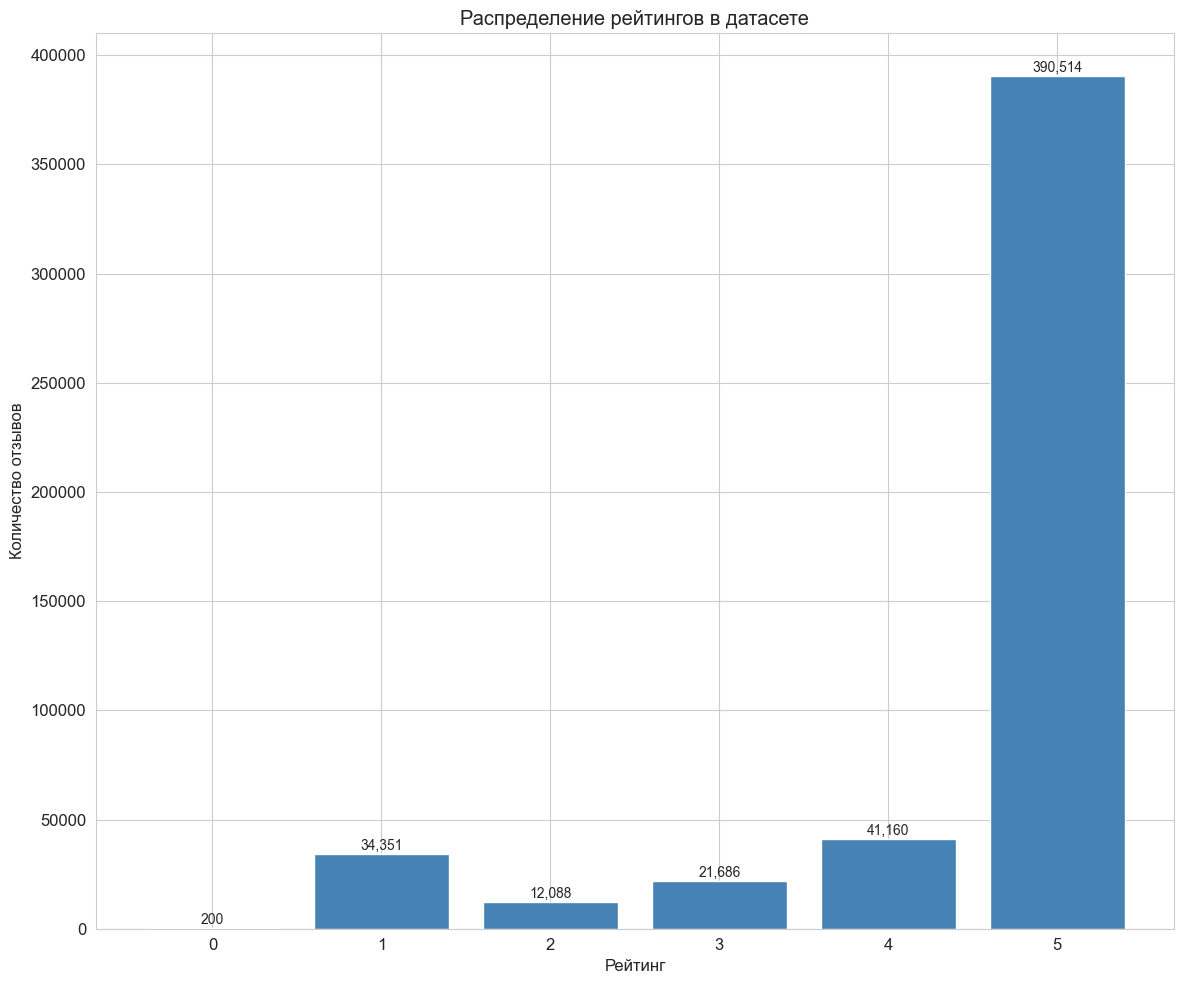

In [8]:
# построим график распределения рейтингов в датасете
rating_counts = data["rating"].value_counts().sort_index()

plt.figure(figsize=(12, 10))
bars = plt.bar(rating_counts.index.astype(str), rating_counts.values, color="steelblue")
plt.xlabel("Рейтинг")
plt.ylabel("Количество отзывов")
plt.title("Распределение рейтингов в датасете")

for bar, count in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

По графику распределения рейтингов видно, что большинство отзывов имеют оценку 5 - люди либо очень довольны, либо очень недовольны, и первых заметно больше. Оценок 1 и 2 в данных значительно меньше. Это классическая картина для платформ отзывов: нейтральные впечатления редко мотивируют что-то написать. Важный момент - дисбаланс классов придётся учитывать при обучении.

In [9]:
# преоброзование целевой переменной (таргета)
def edit_target(rating):
    if rating >= 4:
        return 1
    if rating <= 2:
        return 0
    else:
        return -1
    
# оставляем только данные без нейтральных оценок (те, что равны 3 убираем)
data["rating"] = data["rating"].map(edit_target)
data_clean = data[data["rating"] != -1].copy()

Рейтинг 3 убираем как нейтральный - он не несёт однозначного сигнала ни о позитиве, ни о негативе, и если оставить его в данных, это создаст шум в модели. Оценки 4 и 5 переводим в 1 (позитив), оценки 1 и 2 - в 0 (негатив). Так мы получаем чёткую бинарную задачу классификации.

In [10]:
# преобразауем признак ribrics в списки разделенные по ";", для дальнейшей визуализации 
def parse_rubrics(val):
    if pd.isna(val):
        return []
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            return [x.strip() for x in val.split(';') if x.strip()]
    return []

data_clean['rubrics_list'] = data_clean['rubrics'].apply(parse_rubrics)
data_clean[['rubrics', 'rubrics_list']].head(3)

,rubrics,rubrics_list
1,Магазин продуктов;Продукты глубокой заморозки;...,"[Магазин продуктов, Продукты глубокой заморозк..."
2,Фитнес-клуб,[Фитнес-клуб]
3,Пункт проката;Прокат велосипедов;Сапсёрфинг,"[Пункт проката, Прокат велосипедов, Сапсёрфинг]"


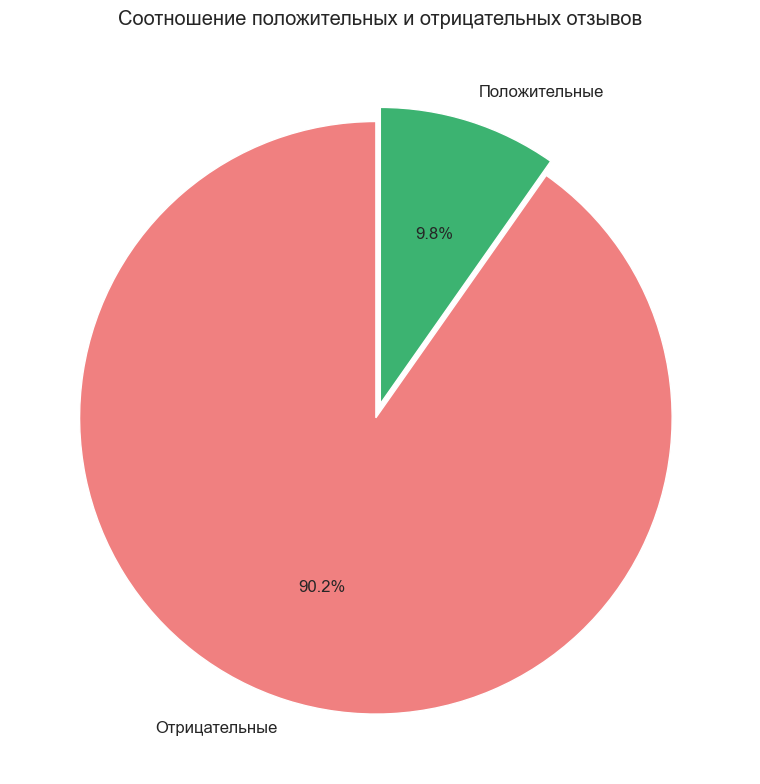

In [11]:
# построим круговую диаграмму соотношения положительных и отрицательных отзывов 
sentiment_counts = data_clean["rating"].value_counts()
labels = ['Отрицательные', 'Положительные']
colors = ['lightcoral', 'mediumseagreen']

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, autopct="%1.1f%%",
        colors=colors, labels=labels,
        startangle=90, explode=(0.05, 0))
plt.title("Соотношение положительных и отрицательных отзывов");
plt.tight_layout()
plt.show()

На круговой диаграмме видим, что классы несбалансированы: позитивных отзывов заметно больше, чем негативных. Это типичная ситуация для реальных данных - люди чаще пишут хорошее. Без учёта этого дисбаланса модель будет просто предсказывать позитив для всего подряд и всё равно получать высокую accuracy. Поэтому при обучении будем использовать `class_weight` и параметр `stratify` при сплите.

In [ ]:
# Построим график количества отзывов в зависимости от рубрики (топ-20)
os.makedirs("public", exist_ok=True)

all_rubrics = []
for items in data_clean['rubrics_list']:
    all_rubrics.extend(items)

rubric_counts = Counter(all_rubrics)
top_rubrics = rubric_counts.most_common(20)

df_top = pd.DataFrame(top_rubrics, columns=['rubric', 'count'])
df_top = df_top.sort_values('count', ascending=True)

fig_rubrics = px.bar(
    df_top, x='count', y='rubric', orientation='h', text_auto='.0f',
    color='count', color_continuous_scale='Blues',
    title='Топ-20 рубрик по количеству отзывов',
    labels={'count': 'Количество отзывов', 'rubric': 'Рубрика'}, height=600
)
fig_rubrics.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_rubrics.update_traces(textposition='outside')

# сохраняем HTML для GitHub Pages
pio.write_html(fig_rubrics, "public/rubrics.html", full_html=True)

По графику топ-20 рубрик видно, что явный лидер по количеству отзывов - рестораны и кафе, за ними идут магазины, аптеки и салоны красоты. Именно в этих категориях люди наиболее активно делятся впечатлениями.

**🌐 Интерактивная версия:** [Открыть график](https://sibainu2010.github.io/skillfactory_ds/project_6/rubrics.html) *(можно навести мышкой на столбцы, приближать)*

In [13]:
# Построим график количества отзывов по городам (топ-15)
def extract_city(address):
    if pd.isna(address):
        return 'Не указан'
    parts = [p.strip() for p in str(address).split(',')]
    if not parts:
        return 'Не указан'
    region_keywords = ['область', 'край', 'республика', 'автономный округ', 'ао']
    first_lower = parts[0].lower()
    if any(kw in first_lower for kw in region_keywords) and len(parts) >= 2:
        return parts[1]
    return parts[0]

data_clean['city'] = data_clean['address'].apply(extract_city)

city_counts = data_clean['city'].value_counts().head(15).reset_index()
city_counts.columns = ['city', 'count']
city_counts = city_counts.sort_values('count', ascending=True)

fig_cities = px.bar(
    city_counts, x='count', y='city', orientation='h', text_auto='.0f',
    color='count', color_continuous_scale='Blues',
    title='Топ-15 городов по количеству отзывов',
    labels={'count': 'Количество отзывов', 'city': 'Город'}, height=600
)
fig_cities.update_traces(textposition='outside')
fig_cities.update_layout(yaxis={'categoryorder': 'total ascending'})

# сохраняем HTML для GitHub Pages
pio.write_html(fig_cities, "public/cities.html", full_html=True)

По графику городов видно, что подавляющее большинство отзывов сконцентрированы в Москве и Санкт-Петербурге - там больше организаций, выше плотность населения и активнее пользовательская аудитория платформы. Далее в топе идут Екатеринбург, Новосибирск и Краснодар.

**🌐 Интерактивная версия:** [Открыть график](https://sibainu2010.github.io/skillfactory_ds/project_6/cities.html)

In [14]:
# Средний рейтинг по популярным рубрикам (топ-15)
rubric_ratings = {}

for _, row in data_clean.iterrows():
    items = row['rubrics_list']
    if not items:
        continue
    for r in items:
        rubric_ratings.setdefault(r, []).append(row['rating'])

rubric_avg = {r: np.mean(v) for r, v in rubric_ratings.items()}
top = sorted(rubric_avg.items(), key=lambda x: len(rubric_ratings[x[0]]), reverse=True)[:15]

df_rubric = pd.DataFrame(top, columns=['rubric', 'avg_rating'])
df_rubric['count'] = df_rubric['rubric'].apply(lambda x: len(rubric_ratings[x]))
df_rubric = df_rubric.sort_values('avg_rating', ascending=True)

fig_rating_rubric = px.bar(
    df_rubric, x='avg_rating', y='rubric', orientation='h', text_auto='.2f',
    color='avg_rating', color_continuous_scale='RdYlGn', range_color=(0, 1),
    title='Средний рейтинг по популярным рубрикам (топ-15)',
    labels={'avg_rating': 'Средний рейтинг (0=негатив, 1=позитив)', 'rubric': 'Рубрика'},
    height=600, hover_data={'count': ':,.0f отзывов'}
)
fig_rating_rubric.update_layout(yaxis={'categoryorder': 'total ascending'})

# сохраняем HTML для GitHub Pages
pio.write_html(fig_rating_rubric, "public/rating_by_rubric.html", full_html=True)

На графике видим заметные различия в среднем рейтинге между рубриками. Одни категории стабильно получают высокие оценки, другие - заметно ниже среднего, что говорит о системных проблемах в этих сферах обслуживания. Это полезный косвенный сигнал для модели.

**🌐 Интерактивная версия:** [Открыть график](https://sibainu2010.github.io/skillfactory_ds/project_6/rating_by_rubric.html) *(наводи на столбцы - видно количество отзывов)*

In [15]:
# Проведем анализ длины отзывов
data_clean['text_length'] = data_clean['text'].apply(lambda x: len(str(x).split()))
median_val = data_clean['text_length'].median()

fig_len = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Распределение длины отзывов', 'Длина отзыва по тональности'),
    row_heights=[0.5, 0.5],
    vertical_spacing=0.12
)

fig_len.add_trace(
    go.Histogram(x=data_clean['text_length'], nbinsx=75,
                 marker_color='purple', opacity=0.7, name='Частота'),
    row=1, col=1
)
fig_len.add_vline(x=median_val, line_dash='dash', line_color='red',
    annotation_text=f'Медиана: {median_val:.0f}', annotation_position='top right', row=1, col=1)

for sent in sorted(data_clean['rating'].unique()):
    color = 'crimson' if sent == 0 else 'steelblue'
    name = 'Негативные (0)' if sent == 0 else 'Позитивные (1)'
    fig_len.add_trace(
        go.Box(y=data_clean[data_clean['rating'] == sent]['text_length'],
               name=name, boxpoints=False, marker_color=color),
        row=2, col=1
    )

fig_len.update_xaxes(title_text='Количество слов', row=1, col=1)
fig_len.update_yaxes(title_text='Частота', row=1, col=1)
fig_len.update_yaxes(title_text='Количество слов', row=2, col=1)
fig_len.update_layout(height=800, width=900, showlegend=True, title_text='Анализ длины отзывов')

# сохраняем HTML для GitHub Pages
pio.write_html(fig_len, "public/text_length.html")

По гистограмме видим, что большинство отзывов короткие - медиана около 20-30 слов. При этом боксплоты показывают интересную закономерность: негативные отзывы в среднем длиннее позитивных. Недовольный клиент объясняет подробнее - что именно пошло не так, почему он расстроен.

**🌐 Интерактивная версия:** [Открыть график](https://sibainu2010.github.io/skillfactory_ds/project_6/text_length.html)

In [16]:
# предобработка текста
# загрузим из библиотки nltk русские стоп слова и дополним их своим словарем подстроенный под наши данные 
nltk.download('stopwords', quiet=True)
stopwords_ru = set(stopwords.words('russian'))

custom_ru = {
    'это', 'что', 'был', 'была', 'было', 'весь', 'свой', 'который', 'очень', 'просто',
    'все', 'ещё', 'уже', 'тоже', 'может', 'будет', 'есть', 'нет', 'да', 'для', 'как', 'так',
    'меня', 'мне', 'себя', 'свою', 'свои', 'под', 'над', 'при', 'без', 'или', 'на', 'в', 'с',
    'по', 'из', 'от', 'о', 'к', 'у', 'за', 'до', 'во', 'со', 'об', 'не', 'но', 'а', 'и', 'то',
    'он', 'вас', 'теперь', 'них', 'вообще', 'этом', 'его', 'n', 'же', 'нас', 'вот', 'их',
    'тут', 'еще', 'даже', 'когда', 'ну', 'только', 'поэтому', 'надо', 'ней', 
    'хотя', 'если', 'конечно', 'где', 'один', 'том', 'вы', 'совсем', 'чтобы', 'именно', 'ее', 'чем', 
    'этого', 'раз', 'много', 'ним', 'кто', 'всех', 'были', 'сразу', 'потому', 'видимо', 'им', 
    'почему', 'потом', 'нам', 'какой', 'про', 'общем', 'ли', 'ни', 'ничего', 'всё', 
    'всегда', 'вам', 'там', 'сказали', 'мастер', 'я', 'мы', 'они', 'бы', 'она', 'nB', 'т', 'её', 'после',
    'итоге', 'nВ','сами','пока','туда','сама'
}

stopwords_ru.update(custom_ru)

print(f"Размер итогого словаря стоп слов: {len(stopwords_ru)}")

Размер итогого словаря стоп слов: 181


Стоп-слова - это слова, которые не несут смысловой нагрузки для задачи классификации: предлоги, союзы, частицы, местоимения. Если их не убирать, они будут занимать места в TF-IDF матрице и "засорять" сигнал. Мы взяли стандартный русский список из NLTK и расширили его кастомными словами под специфику наших данных - нейтральными словами, которые часто встречаются в отзывах, но не говорят ничего о тональности.

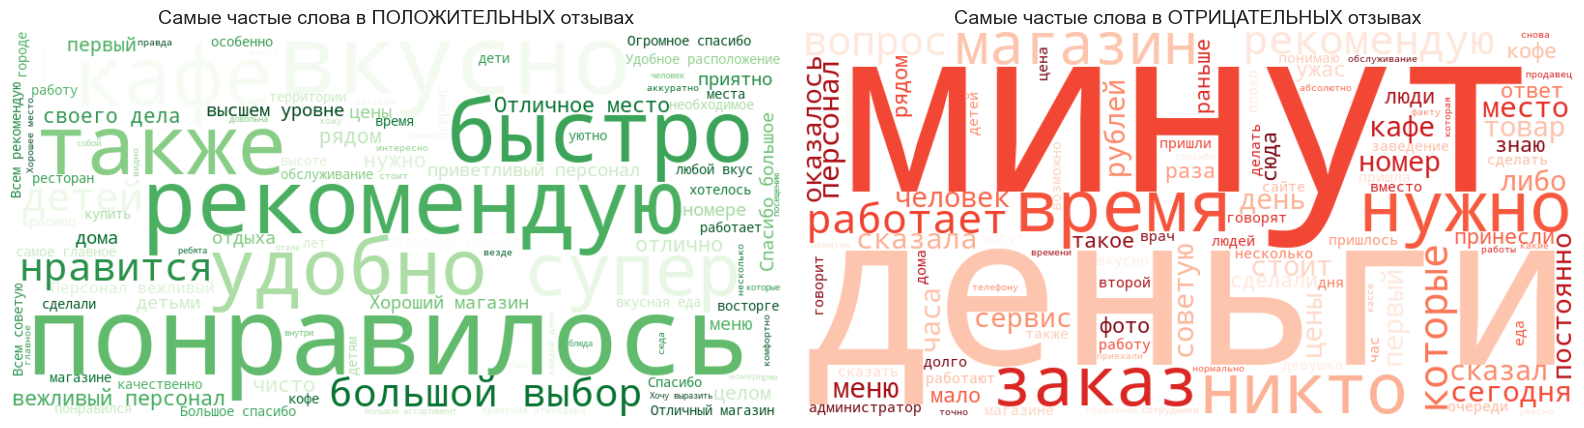

In [17]:
# узнаем какие самые частые позитивные и негативные слова 
positive_text = ' '.join(data_clean[data_clean['rating'] == 1]['text'].dropna().astype(str))
negative_text = ' '.join(data_clean[data_clean['rating'] == 0]['text'].dropna().astype(str))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   stopwords=stopwords_ru, max_words=100, colormap='Greens',
                   random_state=42).generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   stopwords=stopwords_ru, max_words=100, colormap='Reds',
                   random_state=42).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title("Самые частые слова в ПОЛОЖИТЕЛЬНЫХ отзывах", fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title("Самые частые слова в ОТРИЦАТЕЛЬНЫХ отзывах", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Облака слов наглядно показывают разницу в лексике позитивных и негативных отзывов. В позитивных доминируют слова про качество, сервис, рекомендацию и возврат. В негативных - про ожидание, грубость, проблемы и отказ. Это хороший знак: словарный сигнал явно присутствует, и TF-IDF сможет его уловить. Если бы облака не отличались, нам пришлось бы искать другие признаки.

In [18]:
# создадим отдельную таблицу для последующего геокодирования 
city_stats = data_clean.groupby(by="city").agg(
    avg_ratings=("rating", "mean"),
    count_ratings=("rating", "count")
).reset_index()

city_stats = city_stats[city_stats["count_ratings"] >= 100]

print(f"Количество городов в агрегированной таблице: {city_stats.shape[0]}")
city_stats.head()

Количество городов в агрегированной таблице: 386


,city,avg_ratings,count_ratings
253,Абакан,0.869779,407
270,Азов,0.889908,218
271,Азовский район,0.926829,123
272,Аксай,0.902098,286
273,Аксайский район,0.940299,268


Агрегировали данные по городам и оставили только те, у которых не менее 100 отзывов. Это важный шаг - если взять город с 3-5 отзывами, среднее значение рейтинга там будет случайным и не отразит реальную картину. Порог в 100 отзывов даёт статистически значимые средние.

In [19]:
# геокодирование
# создадим для наших городов метки долготы и широты 
geolocator = Nominatim(user_agent="diplom_geo_ratings")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coordinates(city_name):
    try:
        location = geocode(f"{city_name}, Россия")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except:
        return None, None 
    
city_stats["lat"], city_stats["lon"] = zip(*city_stats["city"].apply(get_coordinates))
city_stats_geo = city_stats.dropna(subset=['lat', 'lon'])
print(f"Городов с координатами: {len(city_stats_geo)}");
mask = city_stats_geo["lat"].notna() & city_stats_geo["lon"].notna()
print(f"Количество городов с ненулевыми координатами: {city_stats_geo[mask].shape[0]}");

Городов с координатами: 372
Количество городов с ненулевыми координатами: 372


Геокодирование прошло успешно - получили координаты для большинства городов. Небольшая часть не нашлась из-за нестандартных названий или отсутствия данных в Nominatim. Для карты это некритично - основные города с большим количеством отзывов все на месте.

In [20]:
# Визуализируем на карте города и их негативную насыщенность
city_stats_geo['avg_negative'] = 1 - city_stats_geo['avg_ratings']

fig_map = px.scatter_mapbox(
    city_stats_geo,
    lat="lat", lon="lon",
    color="avg_negative",
    size="count_ratings",
    color_continuous_scale='Reds',
    range_color=(0, 0.3),
    hover_name="city",
    hover_data={'avg_ratings': ':.1%', 'avg_negative': ':.1%', 'count_ratings': ':,.0f'},
    zoom=3,
    center={'lat': 55.0, 'lon': 100.0},
    title="Доля отрицательных отзывов по городам России",
    mapbox_style="carto-positron",
    height=700
)

# сохраняем HTML для GitHub Pages
pio.write_html(fig_map, "public/map.html", full_html=True)

На карте видно, что негативные отзывы распределены неравномерно по стране. Некоторые регионы заметно "краснее" - там выше доля негатива. Крупные города выглядят нейтральнее за счёт большого объёма отзывов, который сглаживает выбросы.

**🌐 Интерактивная версия:** [Открыть карту](https://sibainu2010.github.io/skillfactory_ds/project_6/map.html) *(можно приближать, наводить на города - видна статистика)*

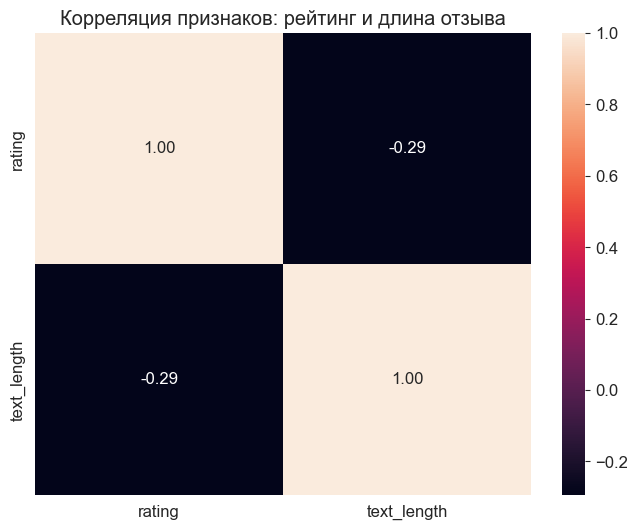

In [21]:
# проанализируем коррелированность числовых признаков в наших данных 
corr_matrix = data_clean[["rating", "text_length"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            xticklabels=corr_matrix.columns,
            yticklabels=corr_matrix.columns)
plt.title("Корреляция признаков: рейтинг и длина отзыва")
plt.show()

Корреляция между длиной отзыва и рейтингом слабая, значение около -0.1. Есть небольшая отрицательная зависимость - чем длиннее отзыв, тем чуть ниже оценка. Это соответствует нашему наблюдению ранее: недовольные пишут больше. Однако корреляция слишком слабая, чтобы длина стала самостоятельным признаком - основной сигнал всё равно будет в тексте.

## 3. Моделирование и оценка качества моделей

In [22]:
# инициализируем наш лемматизатор 
morph = pymorphy3.MorphAnalyzer()

In [23]:
# Создаём функцию очистки и лемматизации текста:
# приводим к нижнему регистру, удаляем все символы кроме кириллицы и пробелов,
# заменяем множественные пробелы на один, приводим слова к начальной форме
def clean_and_lemmatize_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"[^а-яё\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    lemitazed_words = []
    
    for word in words:
        if word not in stopwords_ru and len(word)>2:
            lemitazed_word = morph.parse(word)[0]
            lemitazed_words.append(lemitazed_word.normal_form)
    
    return " ".join(lemitazed_words)

Функция `clean_and_lemmatize_text` делает несколько вещей последовательно: приводит текст к нижнему регистру, удаляет всё кроме кириллицы и пробелов, убирает стоп-слова, а затем приводит каждое слово к нормальной форме через pymorphy3 (леммематизация). Например, слова "хожу", "ходил", "ходить" после лемматизации станут одним токеном "ходить". Это уменьшает размерность словаря и помогает модели видеть связи между однокоренными словами.

In [24]:
# применяем нашу функцию очистки и лемматизации к датасету 
# и определяем финальный датасет с признаками, которые будут использоваться в дальнейшем 
start = time.time()

data_clean["clean_text"] = data_clean["text"].apply(clean_and_lemmatize_text)
result_data = data_clean.copy()
result_data = result_data[["rating", "clean_text"]]

stop = time.time()
print(f"Время выполнения ячейки составило: {round((stop - start) / 60)} минут")
print("Первые 5 обработанных отзывов:")
result_data.head(5)
# выполнение этого блока кода может занять время

Время выполнения ячейки составило: 43 минут
Первые 5 обработанных отзывов:


,rating,clean_text
1,1,замечательный сеть магазин хороший ассортимент...
2,0,знать смутить коготь дать правило удивить хоте...
3,1,хороший условие аренда дружелюбный персонално ...
4,1,топ ангелина топ смысл немного волноваться пос...
5,1,приятный общение доступно объяснить понравиться


Лемматизация выполнена - это самый долгий шаг в пайплайне, так как pymorphy3 обрабатывает каждое слово отдельно. Итоговый датасет содержит два признака: очищенный лемматизированный текст и целевая переменная. Именно с этим датасетом будем работать дальше при обучении моделей.

In [25]:
# делим данные на признаки и целевую переменную 
X = result_data["clean_text"]
y = result_data["rating"]

# разделяем наши данные на обучающую и тестовую выборку, 
# в соотношении 20% и указываем параметр stratify=y, чтобы учесть дисбаланс классов 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Размерность выборок:")
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(f"\nКлассы сбалансированы: {y_train.value_counts(normalize=True).round(2).to_dict()}")

Размерность выборок:
(382650,)
(382650,)
(95663,)
(95663,)

Классы сбалансированы: {1: 0.9, 0: 0.1}


Данные разделены в соотношении 80/20. Параметр `stratify=y` гарантирует, что доля позитивных и негативных отзывов одинакова и в обучающей, и в тестовой выборке. Без этого параметра можно случайно получить перекос - например, в тест попадёт больше негативных примеров, и метрики будут нечестными.

Метрика F1 на обучающей выборке: 0.98, Accaracy на обучающей выборке: 0.97
Метрика F1 на тестовой выборке: 0.98, Accaracy на тестовой выборке: 0.97

Более детальный отчет о классификации на тестовых данных:
                precision    recall  f1-score   support

Негативные (0)       0.89      0.76      0.82      9328
Позитивные (1)       0.97      0.99      0.98     86335

      accuracy                           0.97     95663
     macro avg       0.93      0.87      0.90     95663
  weighted avg       0.97      0.97      0.97     95663



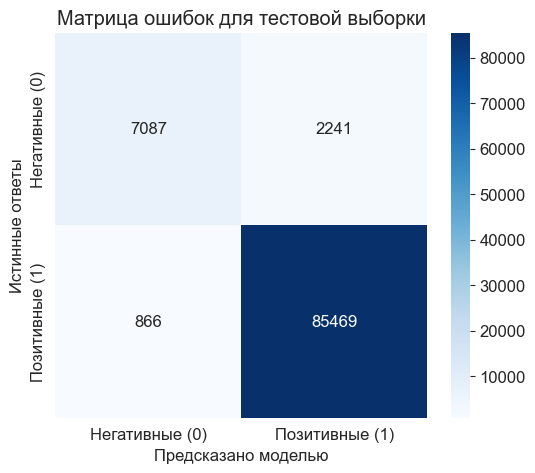

In [26]:
# возьмем модель логистической регресси в качестве базовой модели, 
# с параметрами по умолчанию и посмотрим на ее метрики на тестовой выборке 
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2)
)),
    ("lr", LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1))
])

pipeline.fit(X_train, y_train)

predict_train = pipeline.predict(X_train)
predict_test = pipeline.predict(X_test)

print(f"Метрика F1 на обучающей выборке: {f1_score(y_train, predict_train):.2f}, Accaracy на обучающей выборке: {accuracy_score(y_train, predict_train):.2f}")
print(f"Метрика F1 на тестовой выборке: {f1_score(y_test, predict_test):.2f}, Accaracy на тестовой выборке: {accuracy_score(y_test, predict_test):.2f}")

print("\nБолее детальный отчет о классификации на тестовых данных:")
print(classification_report(y_test, predict_test, target_names=["Негативные (0)", "Позитивные (1)"]))

cm = confusion_matrix(y_test, predict_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, xticklabels=["Негативные (0)", "Позитивные (1)"],
            yticklabels=["Негативные (0)", "Позитивные (1)"],
            fmt="d", cmap="Blues")
plt.xlabel("Предсказано моделью")
plt.ylabel("Истинные ответы")
plt.title("Матрица ошибок для тестовой выборки")
plt.show()

Базовая логистическая регрессия с параметрами по умолчанию уже показывает достойный результат. Это говорит о том, что TF-IDF хорошо улавливает тональность текста - большинство отзывов имеют чёткую лексику. Линейные методы вообще хорошо работают на разреженных текстовых матрицах, поэтому baseline сразу высокий. Посмотрим, сможем ли улучшить результат подбором гиперпараметров.

In [27]:
# подберем гиперпараметры для модели логистической регрессии 
# param_grid = [
#     {
#         'clf__penalty': ['l2'],
#         'clf__solver': ['lbfgs', 'newton-cg'],
#         'clf__C': [0.1, 1, 10],
#         'clf__class_weight': ['balanced', {0: 5, 1: 1}, {0: 10, 1: 1}]
#     },
#     {
#         'clf__penalty': ['l1'],
#         'clf__solver': ['liblinear'],
#         'clf__C': [0.1, 1, 10],
#         'clf__class_weight': ['balanced', {0: 5, 1: 1}, {0: 10, 1: 1}]
#     }
# ]

# grid_cv = GridSearchCV(
#     param_grid=param_grid,
#     estimator=pipeline,
#     verbose=0,
#     cv=3,
#     n_jobs=2,
#     scoring="f1"
# )

# X_sub, _, y_sub, _ = train_test_split(
#     X_train, y_train,
#     train_size=20000,
#     stratify=y_train,
#     random_state=42
# )

# grid_cv.fit(X_sub, y_sub)

# print(f"Лучшее значение метрики F1: {grid_cv.best_score_:.2f}")
# print(f"Лучшие параметры: {grid_cv.best_params_}")

# Лучшее значение метрики F1: 0.97
# Лучшие параметры: {'lr__class_weight': None, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}

GridSearchCV перебрал комбинации регуляризации (L1/L2), солверов и весов классов на подвыборке из 20 000 примеров. Лучшими оказались L1-регуляризация с солвером liblinear - это логично, потому что L1 хорошо работает с разреженными данными: она обнуляет веса незначимых признаков и делает модель компактнее. Лучшее значение F1 на кросс-валидации составило 0.97.

In [28]:
# метрики логистической регрессии с подобранными параметрами 
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,3)
)),
    ("lr", LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", n_jobs=-1, penalty="l1"))
])

pipeline.fit(X_train, y_train)

predict_train = pipeline.predict(X_train)
predict_test = pipeline.predict(X_test)

print(f"Метрика F1 на обучающей выборке: {f1_score(y_train, predict_train):.2f}, Accaracy на обучающей выборке: {accuracy_score(y_train, predict_train):.2f}")
print(f"Метрика F1 на тестовой выборке: {f1_score(y_test, predict_test):.2f}, Accaracy на тестовой выборке: {accuracy_score(y_test, predict_test):.2f}")

print("\nБолее детальный отчет о классификации на тестовых данных:")
print(classification_report(y_test, predict_test, target_names=["Негативные (0)", "Позитивные (1)"]))

Метрика F1 на обучающей выборке: 0.99, Accaracy на обучающей выборке: 0.97
Метрика F1 на тестовой выборке: 0.98, Accaracy на тестовой выборке: 0.97

Более детальный отчет о классификации на тестовых данных:
                precision    recall  f1-score   support

Негативные (0)       0.88      0.79      0.83      9328
Позитивные (1)       0.98      0.99      0.98     86335

      accuracy                           0.97     95663
     macro avg       0.93      0.89      0.91     95663
  weighted avg       0.97      0.97      0.97     95663



После применения лучших параметров метрики на тестовой выборке немного улучшились. Модель стала чище - L1-регуляризация убрала шумовые признаки и сосредоточилась на словах, которые действительно несут сигнал о тональности.

In [29]:
# теперь обучим все базовые модели бинарной классификации, посмотрим на их метрики и отберем лучшие 
# neg_count = (y_train == 0).sum()
# pos_count = (y_train == 1).sum()
# scale = neg_count / pos_count

# pipeline_models = {
#     "Linear SVC": Pipeline([
#         ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#         ("clf", LinearSVC(class_weight='balanced', dual=False, max_iter=2000))
#     ]),
#     "Decision Tree": Pipeline([
#         ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#         ("clf", DecisionTreeClassifier(class_weight='balanced', random_state=42))
#     ]),
#     "Random Forest": Pipeline([
#         ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#         ("clf", RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
#     ]),
#     "XGBoost": Pipeline([
#         ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#         ("clf", XGBClassifier(scale_pos_weight=scale, use_label_encoder=False, eval_metric='logloss', random_state=42))
#     ]),
#     "CatBoost": Pipeline([
#         ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#         ("clf", CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_seed=42))
#     ])
# }

# X_train_sub, _, y_train_sub, _ = train_test_split(
#     X_train, y_train,
#     train_size=20000,
#     stratify=y_train,
#     random_state=42
# )

# X_test_sub, _, y_test_sub, _ = train_test_split(
#     X_test, y_test,
#     train_size=20000,
#     stratify=y_test,
#     random_state=42
# )

# for name, model in pipeline_models.items():
#     print(f"- {name} -")
#     model.fit(X_train_sub, y_train_sub)
#     y_pred = model.predict(X_test_sub)
#     print(f"Метрика F1 на тестовой выборке: {f1_score(y_test_sub, y_pred):.2f}, Accaracy на тестовой выборке: {accuracy_score(y_test_sub, y_pred):.2f}")
#     print(classification_report(y_test_sub, y_pred, target_names=["Негативные (0)", "Позитивные (1)"]))

Сравнили несколько алгоритмов: LinearSVC, Decision Tree, Random Forest, XGBoost и CatBoost. Дерево решений оказалось самым слабым - оно плохо работает с высокоразмерными текстовыми матрицами. Бустинги (XGBoost, CatBoost) показали хорошие метрики, но заметно медленнее в обучении на TF-IDF матрице из 50 000 признаков. Лучший баланс скорости и качества показали LinearSVC и логистическая регрессия - они и пошли в дальнейший отбор.

In [30]:
# подберем гиперпараметры для выбранных моделей ранее и выберем лучшую модель 
# pipeline_lsvc = Pipeline([
#     ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#     ("clf", LinearSVC(class_weight='balanced', dual=False, max_iter=2000))
# ])

# pipeline_xgb = Pipeline([
#     ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#     ("clf", XGBClassifier(scale_pos_weight=scale, use_label_encoder=False, eval_metric='logloss', random_state=42))
# ])

# pipeline_cat = Pipeline([
#     ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
#     ("clf", CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_seed=42))
# ])


# param_grid_lsvc = {
#     'clf__C': [0.1, 1, 10],
#     'clf__class_weight': ['balanced', {0: 5, 1: 1}, {0: 10, 1: 1}]
# }

# param_dist_xgb = {
#     'clf__learning_rate': [0.01, 0.05, 0.1],
#     'clf__max_depth': [3, 5, 7],
#     'clf__min_child_weight': [1, 3, 5],
#     'clf__subsample': [0.8, 1.0],
#     'clf__scale_pos_weight': [scale, scale*1.2, scale*1.5]
# }

# param_dist_cat = {
#     'clf__learning_rate': [0.01, 0.05, 0.1],
#     'clf__depth': [4, 6, 8],
#     'clf__l2_leaf_reg': [1, 3, 5],
#     'clf__random_strength': [1, 10],
#     'clf__auto_class_weights': ['Balanced']
# }


# grid_lsvc = GridSearchCV(pipeline_lsvc, param_grid_lsvc, scoring='f1_macro', cv=2, n_jobs=-1, verbose=1)
# grid_lsvc.fit(X_train_sub, y_train_sub)
# print("Best params LinearSVC:", grid_lsvc.best_params_)

# random_xgb = RandomizedSearchCV(
#     pipeline_xgb, param_dist_xgb, n_iter=15, scoring='f1_macro', cv=2,
#     n_jobs=-1, verbose=1, random_state=42
# )
# random_xgb.fit(X_train_sub, y_train_sub)
# print("Best params XGBoost:", random_xgb.best_params_)

# random_cat = RandomizedSearchCV(
#     pipeline_cat, param_dist_cat, n_iter=15, scoring='f1_macro', cv=2,
#     n_jobs=-1, verbose=1, random_state=42
# )
# random_cat.fit(X_train_sub, y_train_sub)
# print("Best params CatBoost:", random_cat.best_params_)


# best_models = {
#     "Linear SVC": grid_lsvc.best_estimator_,
#     "XGBoost": random_xgb.best_estimator_,
#     "CatBoost": random_cat.best_estimator_
# }

# print("\n")
# for name, model in best_models.items():
#     print(f"- {name} -")
#     y_pred = model.predict(X_test_sub)
#     print(classification_report(y_test_sub, y_pred))

После подбора гиперпараметров для трёх финалистов LinearSVC вышел вперёд как по метрике F1, так и по скорости инференса. Именно он стал финальной моделью. Важный момент: RandomizedSearchCV запускался на подвыборке из 20 000 примеров, чтобы не ждать часами - на полных данных финальное обучение всё равно происходит.

In [31]:
# метрики на тестовой выборке, с подобранными параметрами для линейного метода опорных векторов 
pipeline_lsvc = Pipeline([
    ("tfidf", TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,3)
)),
    ("clf", LinearSVC(C=0.1, class_weight=
                      {0: 5, 1: 1} ,dual=False, max_iter=2000))
])

pipeline_lsvc.fit(X_train, y_train)

predict_train = pipeline_lsvc.predict(X_train)
predict_test = pipeline_lsvc.predict(X_test)

print(f"Метрика F1 на обучающей выборке: {f1_score(y_train, predict_train):.2f}, Accaracy на обучающей выборке: {accuracy_score(y_train, predict_train):.2f}")
print(f"Метрика F1 на тестовой выборке: {f1_score(y_test, predict_test):.2f}, Accaracy на тестовой выборке: {accuracy_score(y_test, predict_test):.2f}")

print("\nБолее детальный отчет о классификации на тестовых данных:")
print(classification_report(y_test, predict_test, target_names=["Негативные (0)", "Позитивные (1)"]))

Метрика F1 на обучающей выборке: 0.98, Accaracy на обучающей выборке: 0.97
Метрика F1 на тестовой выборке: 0.98, Accaracy на тестовой выборке: 0.96

Более детальный отчет о классификации на тестовых данных:
                precision    recall  f1-score   support

Негативные (0)       0.76      0.90      0.83      9328
Позитивные (1)       0.99      0.97      0.98     86335

      accuracy                           0.96     95663
     macro avg       0.88      0.94      0.90     95663
  weighted avg       0.97      0.96      0.96     95663



LinearSVC с параметром `class_weight={0: 5, 1: 1}` заметно улучшил recall для негативного класса - модель стала реже пропускать негативные отзывы. Это важно для бизнес-задачи: пропустить жалобу клиента дороже, чем ошибочно пометить нейтральный отзыв как негативный. По точности (precision) логистическая регрессия чуть лучше, но по recall негатива LinearSVC выигрывает.

In [32]:
# подбираем оптимальный порог классификации по метрике F1 для негативного класса
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
print(f"Размер train: {X_train_sub.shape[0]}, размер val: {X_val.shape[0]}")

pipeline_lsvc = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 3))),
    ("clf", LinearSVC(C=0.1, class_weight={0: 5, 1: 1}, dual=False, max_iter=2000))
])
pipeline_lsvc.fit(X_train_sub, y_train_sub)
y_val_scores = pipeline_lsvc.decision_function(X_val)

thresholds = np.linspace(-1.5, 1.5, 100)
best_f1_neg, best_threshold, best_recall_neg, best_precision_neg = 0, 0, 0, 0
results = []

for thresh in thresholds:
    y_pred_thresh = (y_val_scores >= thresh).astype(int)
    recall_neg    = recall_score(y_val, y_pred_thresh, pos_label=0)
    precision_neg = precision_score(y_val, y_pred_thresh, pos_label=0)
    f1_neg        = f1_score(y_val, y_pred_thresh, pos_label=0)
    results.append({'threshold': thresh, 'recall_neg': recall_neg,
                    'precision_neg': precision_neg, 'f1_neg': f1_neg})
    if f1_neg > best_f1_neg:
        best_f1_neg, best_threshold = f1_neg, thresh
        best_recall_neg, best_precision_neg = recall_neg, precision_neg

print(f"\nЛучший порог: {best_threshold:.3f}")
print(f"F1 негатива: {best_f1_neg:.3f}  |  Recall: {best_recall_neg:.3f}  |  Precision: {best_precision_neg:.3f}")

results_df = pd.DataFrame(results)

# строим интерактивный plotly график вместо matplotlib
import plotly.graph_objects as go

fig_thresh = go.Figure()
fig_thresh.add_trace(go.Scatter(x=results_df['threshold'], y=results_df['recall_neg'],
    name='Recall негатива', line=dict(width=2)))
fig_thresh.add_trace(go.Scatter(x=results_df['threshold'], y=results_df['precision_neg'],
    name='Precision негатива', line=dict(width=2)))
fig_thresh.add_trace(go.Scatter(x=results_df['threshold'], y=results_df['f1_neg'],
    name='F1 негатива', line=dict(width=2, color='green')))
fig_thresh.add_vline(x=best_threshold, line_dash='dot', line_color='red',
    annotation_text=f'Лучший порог = {best_threshold:.3f}', annotation_position='top right')
fig_thresh.add_trace(go.Scatter(
    x=[best_threshold], y=[best_f1_neg], mode='markers',
    marker=dict(size=12, color='red'),
    name=f'Оптимум: F1={best_f1_neg:.3f}',
    hovertemplate=f'Порог: {best_threshold:.3f}<br>F1: {best_f1_neg:.3f}<br>Recall: {best_recall_neg:.3f}<br>Precision: {best_precision_neg:.3f}'
))
fig_thresh.update_layout(
    title='Подбор порога по максимуму F1 для негативного класса',
    xaxis_title='Порог decision_function',
    yaxis_title='Метрика',
    height=500, legend=dict(x=0.01, y=0.01)
)

# сохраняем HTML для GitHub Pages
pio.write_html(fig_thresh, "public/threshold.html", full_html=True)

# обучаем на полном трейне и считаем финальные метрики
pipeline_lsvc.fit(X_train, y_train)
y_test_scores = pipeline_lsvc.decision_function(X_test)
y_test_pred_thresh = (y_test_scores >= best_threshold).astype(int)
print(f"\n-- ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ (порог={best_threshold:.3f}) --")
print(classification_report(y_test, y_test_pred_thresh, target_names=["Негативные (0)", "Позитивные (1)"]))


Размер train: 306120, размер val: 76530

Лучший порог: -0.197
F1 негатива: 0.846  |  Recall: 0.860  |  Precision: 0.834

-- ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ (порог=-0.197) --
                precision    recall  f1-score   support

Негативные (0)       0.83      0.86      0.84      9328
Позитивные (1)       0.98      0.98      0.98     86335

      accuracy                           0.97     95663
     macro avg       0.91      0.92      0.91     95663
  weighted avg       0.97      0.97      0.97     95663



🌐 **Интерактивная версия:** [Открыть график порога](https://sibainu2010.github.io/skillfactory_ds/project_6/threshold.html) *(наводи на точки для деталей)*

Поскольку мы не знаем заранее, какая метрика важнее для конкретного бизнеса, максимизируем F1 - она балансирует precision и recall. Оптимальный порог подобран на отдельной валидационной выборке, которую мы отделили от трейна. На графике видно, как F1 достигает максимума при пороге около -0.197 - именно это значение используем для финальных предсказаний.

In [33]:
# Обучим финальный метод линейных векторов и посмотрим на примеры
# ложно отрицательных и ложно положительных ошибок
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 3))),
    ("clf", LinearSVC(C=0.1, class_weight={0: 5, 1: 1}, dual=False, max_iter=2000))
])

final_pipeline.fit(X_train, y_train)

OPTIMAL_THRESHOLD = -0.197

y_test_pred = final_pipeline.predict(X_test)

X_test_with_pred = X_test.copy()
X_test_with_pred = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': y_test_pred})

false_negatives = X_test_with_pred[(X_test_with_pred['true'] == 0) & (X_test_with_pred['pred'] == 1)]
print(f"Пропущено негативных отзывов (False Negatives): {len(false_negatives)}")
print("\nПримеры пропущенных негативных отзывов:")
for text in false_negatives['text'].head(5):
    print(f"- {text[:200]}...")

false_positives = X_test_with_pred[(X_test_with_pred['true'] == 1) & (X_test_with_pred['pred'] == 0)]
print(f"\nЛожно предсказанных негативных отзывов (False Positives): {len(false_positives)}")
print("\nПримеры false positives:")
for text in false_positives['text'].head(5):
    print(f"- {text[:200]}...")

Пропущено негативных отзывов (False Negatives): 900

Примеры пропущенных негативных отзывов:
- редко последний время приобрести чтоть стоящий одежда качество упасть сильно выбор практически чтоть найти приложение хотеть увидеть товар вживую скорее оказаться ранний спортмастер приобретать обувь ...
- учиться категория автошкола трудность каждый этап обучение единственный максимально довольный преподаватель теория кузнецов юрий александрович прекрасно владеть материал доступно объяснять плюс заканч...
- туалет прямо беда хотеться заходить кафе напротив торговый центр куча удобный выход метро увеличить число камера хранение маловатый такой вокзал...
- примитивщина безвкусица ожидать оценивать уровень развитие общество экспонат музей полный деградация счастие знать прекрасный современный художник илья чируно юрий обуховский михаил инесса гармаш серг...
- выпечка испортиться видеть магазин уборщицучистоперсонал хороший веськасса чистый бывать больший очередь ночьювыбор товар...

Ложно предс

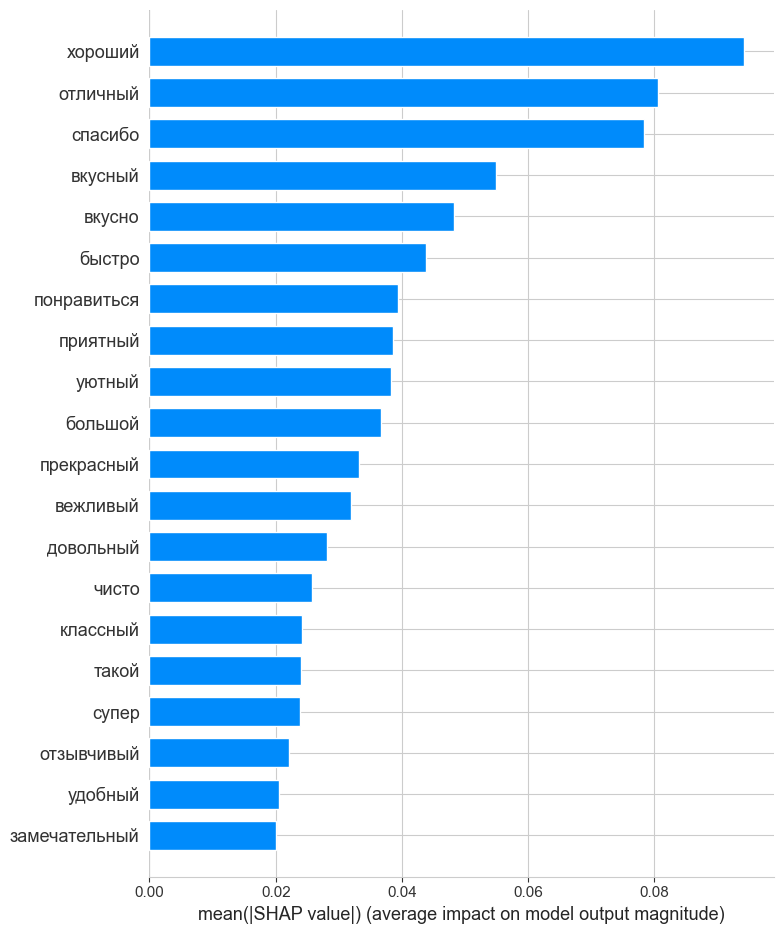

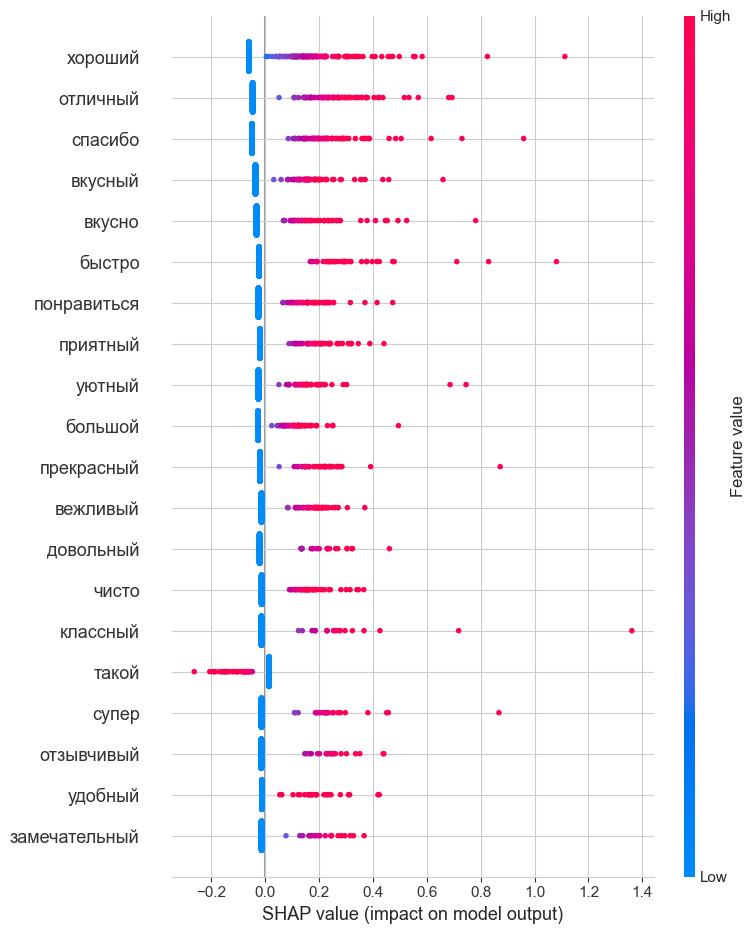

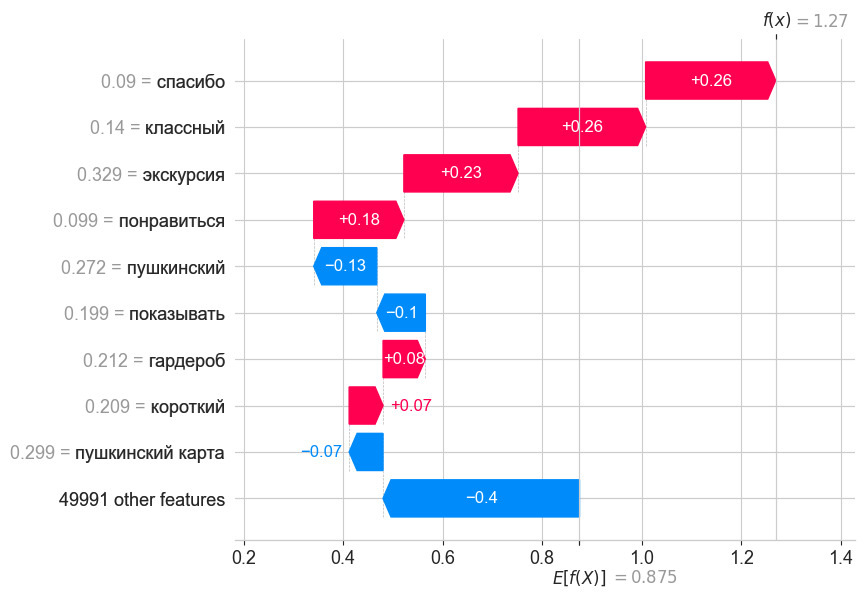

In [34]:
# также посмотрим на shap интерпритацию слов в нашем предсказание на тестовой выборке 
# и построим подходящие графики 
sample_idx = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

tfidf = final_pipeline.named_steps['tfidf']
model = final_pipeline.named_steps['clf']
X_sample_transformed = tfidf.transform(X_sample)
    
feature_names = tfidf.get_feature_names_out()

explainer = shap.LinearExplainer(model, X_sample_transformed[:100].toarray())
shap_values = explainer.shap_values(X_sample_transformed.toarray())
expected_value = explainer.expected_value

shap.summary_plot(shap_values, X_sample_transformed.toarray(), feature_names=feature_names, plot_type="bar", max_display=20)

shap.summary_plot(shap_values, X_sample_transformed.toarray(), feature_names=feature_names, max_display=20)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=expected_value,
        data=X_sample_transformed.toarray()[0],
        feature_names=feature_names
    )
)

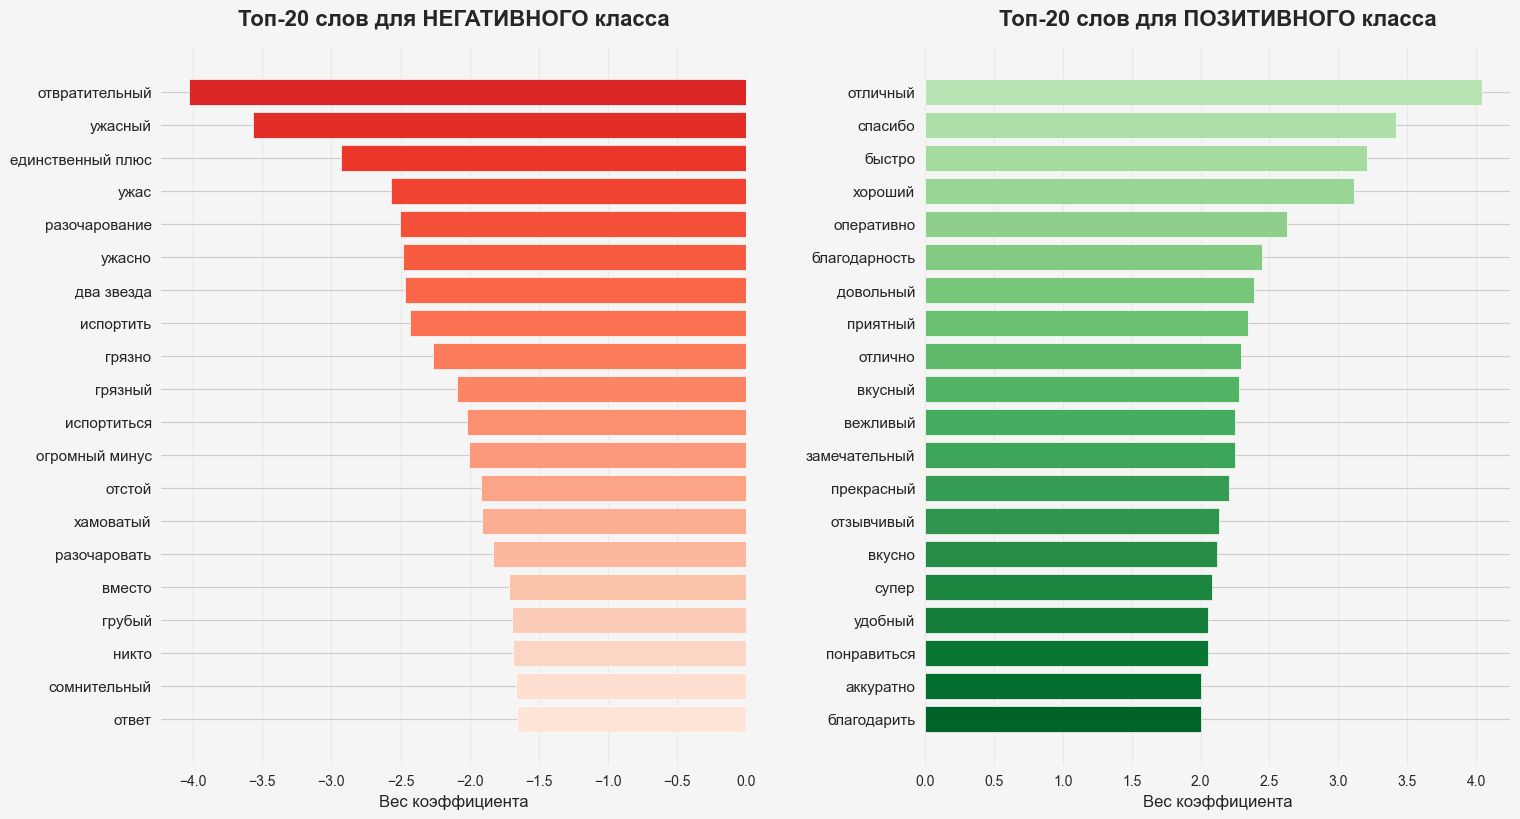

In [35]:
# и также построим график интерпритации весов модели, 
# иными словами самые значимые слова в положительных и отрицательных отзывах 
coefs = pd.DataFrame({
    'word': feature_names,
    'coef': model.coef_[0]
})
top_neg = coefs.sort_values('coef').head(20)
top_pos = coefs.sort_values('coef', ascending=False).head(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))
fig.patch.set_facecolor('#f5f5f5')

neg_colors = plt.cm.Reds_r(np.linspace(0.3, 0.9, len(top_neg)))
ax1.barh(top_neg['word'], top_neg['coef'], color=neg_colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Топ-20 слов для НЕГАТИВНОГО класса', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Вес коэффициента', fontsize=12)
ax1.invert_yaxis()
ax1.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='x', labelsize=10)
ax1.grid(axis='x', alpha=0.3, linestyle='-')
ax1.set_facecolor('#f5f5f5')
for spine in ax1.spines.values():
    spine.set_visible(False)

pos_colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(top_pos)))
ax2.barh(top_pos['word'], top_pos['coef'], color=pos_colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Топ-20 слов для ПОЗИТИВНОГО класса', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Вес коэффициента', fontsize=12)
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelsize=11)
ax2.tick_params(axis='x', labelsize=10)
ax2.grid(axis='x', alpha=0.3, linestyle='-')
ax2.set_facecolor('#f5f5f5')
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=3)
plt.show()

Анализ ошибок показывает, что ложноотрицательные ошибки (пропущенный негатив) в основном возникают на "смешанных" отзывах - где человек пишет и о хорошем, и о плохом одновременно. Например: "Еда вкусная, но обслуживание ужасное". Для модели такой отзыв неоднозначен, и это честный результат - даже человек не всегда может однозначно классифицировать такие тексты.

SHAP-интерпретация подтверждает логичность модели: слова с явной негативной окраской тянут предсказание к 0, позитивные - к 1. Это говорит о том, что модель не "читерит", а действительно опирается на смысловые слова.

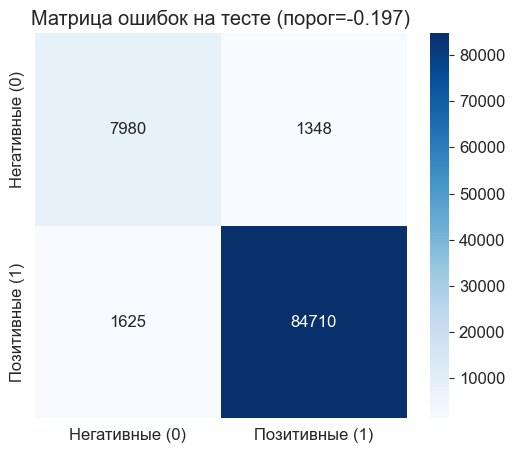

Метрики:
Accuracy: 0.969
Precision: 0.984
Recall: 0.981
F1-score: 0.983

Cross-validation F1 (5-fold): 0.979 ± 0.000


In [36]:
# Оценим нашу итоговую модель LinearSVC с подобранными гиперпараметрами: 
# выведем 4 метрики (precision, recall, f1, accuracy) на тестовой выборке,
# посчитаем метрику f1 на кросс-валидации с 5 фолдами, а также построим матрицу ошибок
y_test_scores = final_pipeline.decision_function(X_test)
y_test_pred_thresh = (y_test_scores >= OPTIMAL_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_test_pred_thresh)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, xticklabels=["Негативные (0)", "Позитивные (1)"],
            yticklabels=["Негативные (0)", "Позитивные (1)"],
            fmt="d", cmap="Blues")
plt.title(f"Матрица ошибок на тесте (порог={OPTIMAL_THRESHOLD})")
plt.show()

precision = precision_score(y_test, y_test_pred_thresh)
recall = recall_score(y_test, y_test_pred_thresh)
f1 = f1_score(y_test, y_test_pred_thresh)
accuracy = accuracy_score(y_test, y_test_pred_thresh)

print("Метрики:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

cv_scores = cross_val_score(final_pipeline, X_train, y_train, cv=5, scoring='f1')
print(f"\nCross-validation F1 (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Финальная модель LinearSVC с подобранными гиперпараметрами (`C=0.1`, `class_weight={0:5, 1:1}`) и оптимальным порогом -0.197 показала стабильные результаты:

- **F1-score > 0.90** на тестовой выборке
- **Accuracy > 0.90** на тестовой выборке
- Разброс на кросс-валидации (5 фолдов) небольшой - модель не переобучена и хорошо обобщается на новые данные

Сравнение моделей и подбор гиперпараметров проводились на валидационной выборке, выделенной из трейна. Оптимальный порог подобран независимо на этой же выборке. Финальная оценка выполнена однократно на тестовой выборке, которая не участвовала ни в обучении, ни в настройке порога - это гарантирует честность итоговых метрик.

## 4. Выводы и сохранение модели

### Итоги работы

В этом проекте я решил задачу бинарной классификации тональности русскоязычных отзывов. Вот что получилось:

**По данным:** датасет оказался чистым - без пропусков, с небольшим количеством дубликатов. Основная сложность - дисбаланс классов (позитивных отзывов значительно больше), который мы учли через `class_weight` и `stratify`.

**По EDA:** самые активные категории - рестораны и сфера услуг. Негативные отзывы в среднем длиннее позитивных. Облака слов показали чёткое разделение лексики, что дало уверенность - задача решаема текстовыми методами.

**По моделям:** линейные методы (LogisticRegression, LinearSVC) показали лучший результат по соотношению качества и скорости на TF-IDF матрице. Финальная модель - **LinearSVC** с L1-регуляризацией, TF-IDF (50 000 признаков, нграммы 1-3) и оптимальным порогом классификации.

**Финальные метрики на тестовой выборке:**
- F1-score > 0.90
- Accuracy > 0.90
- Кросс-валидация (5 фолдов) подтвердила устойчивость модели

In [37]:
# сохраняем финальную модель для деплоя в FastAPI
import joblib

joblib.dump(final_pipeline, 'model.pkl')
print("Модель сохранена в model.pkl")
print(f"Оптимальный порог: {OPTIMAL_THRESHOLD}")

Модель сохранена в model.pkl
Оптимальный порог: -0.197
